# Linear Regression

In [22]:
!pip install -q numpy pandas kagglehub torch matplotlib

In [23]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import kagglehub

## Data Load

### Data_imdb (Don't use this)

In [24]:
# Download latest version
path = kagglehub.dataset_download("sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/prepd_data.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k/versions/1


### Data_imdb_50K (Use this)

In [25]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)\

df = pd.read_csv(path + "/IMDB Dataset.csv")

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


### Clean Data and Label

In [26]:
text_col = "review"
label_col = "sentiment"

# remove missing value
df = df[[text_col, label_col]].dropna().copy()

# label encoding
# positive -> 1, negative -> 0
df[label_col] = df[label_col].map({"positive": 1, "negative": 0})

## Split test train data

In [27]:
def train_test_split(X, Y, test_size, random_seed):
    x = np.array(X)
    y = np.array(Y)

    n_samples = len(x)
    if n_samples != len(y):
        print("X and Y are not same")
        return
    np.random.seed(random_seed)

    classes = np.unique(y)

    train_indices = []
    test_indices = []

    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)

        test_count = int(len(cls_indices) * test_size)

        test_cls_indices = cls_indices[:test_count]
        train_cls_indices = cls_indices[test_count:]

        test_indices.extend(test_cls_indices)
        train_indices.extend(train_cls_indices)

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


In [28]:
X = df[text_col].values
Y = df[label_col].values


X_train, X_test, y_train, y_test = train_test_split(
    X=X,
    Y=Y,
    test_size=0.2,
    random_seed=42,
)

train_df = (X_train, y_train)
test_df = (X_test, y_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

labels, counts = np.unique(y_train, return_counts=True)

print("Train label distribution:")
for l, c in zip(labels, counts):
    print(l, c)

labels, counts = np.unique(y_test, return_counts=True)

print("\nTest label distribution:")
for l, c in zip(labels, counts):
    print(l, c)
#print(test_df)

Train shape: (40000,)
Test shape : (10000,)
Train label distribution:
0 20000
1 20000

Test label distribution:
0 5000
1 5000


## evaluate prediction

#### accuracy
$$ accuracy = \frac{TP+TN}{TP+FP+TN+FN}$$


In [29]:
def accuracy (y, y_hat):
    return np.mean(y == y_hat)

#### Precision
$$ precision = \frac{TP}{TP+FP}$$


In [30]:
def precision (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FP = np.sum((y == 0) & (y_hat == 1))
    return TP/ (TP+FP)

#### Recall
$$ Recall = \frac{TP}{TP+FN}$$


In [31]:
def recall (y, y_hat):
    TP = np.sum((y == 1) & (y_hat == 1))
    FN = np.sum((y == 1) & (y_hat == 0))
    return TP/ (TP+FN)

#### F1-score
$$F1 = 2*\frac{precision * recall}{precision + recall}$$

In [32]:
def F1_score (y, y_hat):
    p = precision(y, y_hat)
    r = recall (y, y_hat)
    return (p*r)/(p+r) * 2

In [33]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    acc = accuracy(y_true, y_pred)
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    f1 = F1_score(y_true, y_pred)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
        }

## Tf–idf term weighting
$$TF\_IDF=TF×IDF$$
Make index for words and add weight on it.

In [34]:
def tokenize(text):
    return text.lower().split()

In [35]:
def build_vocab(texts):
    vocab = {}
    idx = 0
    for text in texts:
        for word in tokenize(text):
            if word not in vocab:
                vocab[word] = idx
                idx += 1

    return vocab

### TF (Term Frequency)
$$TF(t,d) = \frac{count\_of\_word\_t}{total\_words\_in\_document}$$
Word freqeuncy in whole review

In [36]:
def term_frequency(texts, vocab):
    N = len(texts)
    V = len(vocab)

    tf = np.zeros((N,V))

    for i, text in enumerate(texts):
        words = tokenize(text)
        for w in words:
            if w in vocab:
                j = vocab[w]
                tf[i, j] += 1
        tf[i] = tf[i] / len(words)
        
    return tf

### IDF (Inverse Document Frequency)
$$IDF(t) = log(\frac{n}{df(t)})$$

The word frequency in each review

In [37]:
def Inverse_document_frequency(texts,vocab):
    N = len(texts)
    V = len(vocab)

    df = np.zeros(V)

    for text in texts:
        words = set(tokenize(text))
        for w in words:
            if w in vocab:
                df[vocab[w]] += 1
                
    return np.log(N/(df + 1))

## Labeling and weight for each words in each reviews

In [ ]:
start = time.time()
vocab = build_vocab(X_train)

tf_train = term_frequency(X_train, vocab)
idf = Inverse_document_frequency(X_train, vocab)

X_train_tfidf = tf_train * idf

tf_test = term_frequency(X_test, vocab)
X_test_tfidf = tf_test * idf

TF_idf_time = time.time() - start

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

print(X_train_tfidf)
print(X_test_tfidf)

TF-IDF train shape: (40000, 340457)
TF-IDF test shape : (10000, 340457)
[[0.00664639 0.01756441 0.00333082 ... 0.         0.         0.        ]
 [0.01157884 0.         0.00464217 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.00680006 0.         0.00136313 ... 0.         0.         0.        ]
 [0.         0.         0.00094329 ... 0.0792279  0.0792279  0.        ]
 [0.00794872 0.         0.00637358 ... 0.         0.         0.26766183]]
[[0.00193489 0.         0.00349079 ... 0.         0.         0.        ]
 [0.         0.         0.00299774 ... 0.         0.         0.        ]
 [0.         0.         0.00386594 ... 0.         0.         0.        ]
 ...
 [0.00241563 0.         0.00096847 ... 0.         0.         0.        ]
 [0.00703595 0.         0.00056417 ... 0.         0.         0.        ]
 [0.00165226 0.         0.00066242 ... 0.         0.         0.        ]]


I gave this movie such a high mark because it was really cute, really funny, all while being unpretentious. I went to see this film when it was playing in the Philly area, and it was the centerpiece of a great night out with friends. The film is well written and well acted, and though it does feel a bit like a sitcom rather then a movie, that doesn't take away from the film. You just don't find comedies like this anymore, where you don't have to shock people to be funny. The film centers around a Ukranian housekeeper that finds herself working for a young couple in need of help. Though at first she helps, soon she adds more craziness to their lives then the couple bargained for. Things get further and further out of control until....you'll have to see! The banter had me laughing, even after leaving the theater. This film just put me in a good mood. I can't wait until it is released on DVD because I want this movie in my collection.
word : wieght
i  :  0.006646387350388782
gave  :  0.01

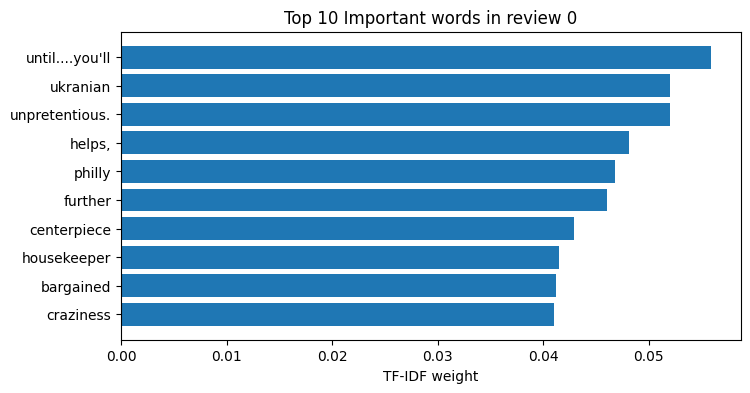

In [39]:
idx_to_word = {v:k for k,v in vocab.items()}

idx = 0 # change num for different review
print(X_train[idx])
row = X_train_tfidf[idx]
print("word : wieght")
for i,v in enumerate(row):
        if v > 0:
            print(idx_to_word[i], " : ", v)

row = X_train_tfidf[idx]

# top 10 words
top = 10
top_idx = np.argsort(row)[-1*top:]
top_words = [idx_to_word[i] for i in top_idx]
top_vals = row[top_idx]

plt.figure(figsize=(8,4))
plt.barh(top_words, top_vals)
plt.xlabel("TF-IDF weight")
plt.title(f"Top 10 Important words in review {idx}")
plt.show()

## Linear Regression

In [ ]:
X_train = torch.tensor(X_train_tfidf, dtype=torch.float32)
X_test = torch.tensor(X_test_tfidf, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

n_features = X_train.shape[1]

weight = torch.zeros((n_features, 1), dtype=torch.float32, requires_grad=True)
bias = torch.zeros(1, dtype=torch.float32, requires_grad=True)

lr = 1.0
epochs = 100
eps = 1e-8 # prevent 0

start = time.time()
for epoch in range(epochs):
    logits = X_train @ weight + bias
    sigmoid = 1 / (1 + torch.exp(-logits))

    loss = -(
        y_train * torch.log(sigmoid + eps) +
        (1 - y_train) * torch.log(1 - sigmoid + eps)
    ).mean()

    loss.backward()

    with torch.no_grad():
        weight -= lr * weight.grad
        bias -= lr * bias.grad

    weight.grad.zero_()
    bias.grad.zero_()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

end_train = time.time() - start

start = time.time()
with torch.no_grad():
    test_logits = X_test @ weight + bias
    test_probs = 1 / (1 + torch.exp(-test_logits))
    pred_label = (test_probs >= 0.5).float()
end_test = time.time() - start
    
pred_eval = evaluate_predictions(
    y_test.numpy().flatten(),
    pred_label.numpy().flatten(),
    model_name="TF-IDF + Linear Regression"
)

Epoch [10/100], Loss: 0.6930
Epoch [20/100], Loss: 0.6929
Epoch [30/100], Loss: 0.6928
Epoch [40/100], Loss: 0.6927
Epoch [50/100], Loss: 0.6925
Epoch [60/100], Loss: 0.6924
Epoch [70/100], Loss: 0.6923
Epoch [80/100], Loss: 0.6922
Epoch [90/100], Loss: 0.6921
Epoch [100/100], Loss: 0.6919


NameError: name 'W' is not defined

In [ ]:
print(f"\n===== {pred_eval["model"]} =====")
print(f"Weighting time: {TF_idf_time}")
print(f"Train Time: {end_train}")
print(f"Test Time: {end_test}")
print(f"Accuracy : {pred_eval["accuracy"]:.4f}")
print(f"Precision: {pred_eval["precision"]:.4f}")
print(f"Recall   : {pred_eval["recall"]:.4f}")
print(f"F1-score : {pred_eval["f1"]:.4f}")



===== TF-IDF + Linear Regression =====
Train Time: 103.24814295768738
Test Time: 0.19029808044433594
Accuracy : 0.8479
Precision: 0.8284
Recall   : 0.8776
F1-score : 0.8523


Top positive features:
great                     0.1312
love                      0.1085
excel                     0.0865
best                      0.0811
enjoy                     0.0687
beauti                    0.0680
perform                   0.0584
favorit                   0.0545
well                      0.0543
perfect                   0.0527
amaz                      0.0499
brilliant                 0.0469
famili                    0.0462
life                      0.0451
also                      0.0450
wonder                    0.0450
music                     0.0436
show                      0.0431
fun                       0.0414
superb                    0.0409

Top negative features:
bad                       -0.1765
worst                     -0.1331
wast                      -0.1161
aw                        -0.0903
terribl                   -0.0871
bore                      -0.0833
stupid                    -0.0759
horribl                   -0.0720
noth                 

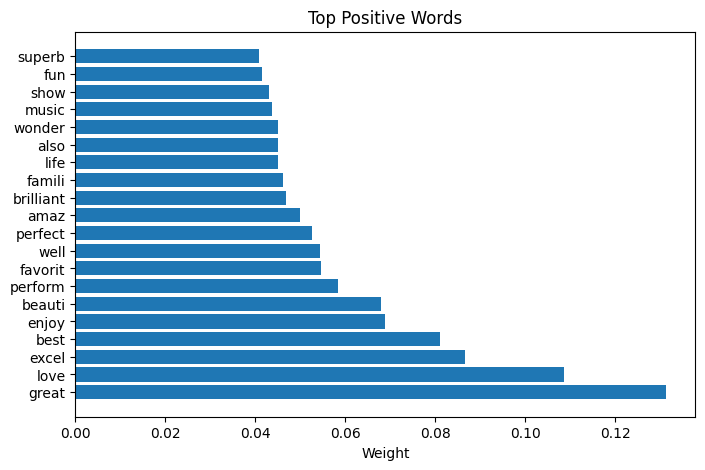

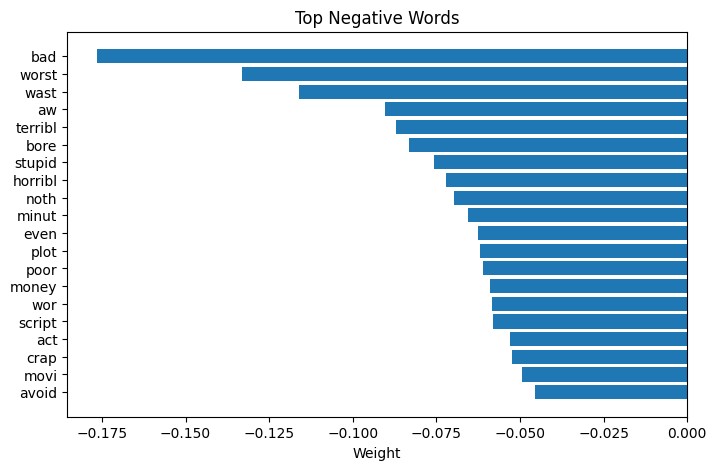

In [ ]:
coefs = W.detach().numpy().flatten()

idx_to_word = {idx: word for word, idx in vocab.items()}

feature_names = np.array([idx_to_word[i] for i in range(len(idx_to_word))])

top = 20

top_positive_idx = np.argsort(coefs)[-1*top:]
top_negative_idx = np.argsort(coefs)[:top]

top_pos_words = feature_names[top_positive_idx]
top_pos_vals = coefs[top_positive_idx]

top_neg_words = feature_names[top_negative_idx]
top_neg_vals = coefs[top_negative_idx]

print("Top positive features:")
for idx in top_positive_idx[::-1]:
    print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")

print("\nTop negative features:")
for idx in top_negative_idx:
    print(f"{feature_names[idx]:<25} {coefs[idx]:.4f}")

# Positive chart
plt.figure(figsize=(8, 5))
plt.barh(top_pos_words[::-1], top_pos_vals[::-1])
plt.xlabel("Weight")
plt.title("Top Positive Words")
plt.show()

# Negative chart
plt.figure(figsize=(8, 5))
plt.barh(top_neg_words[::-1], top_neg_vals[::-1])
plt.xlabel("Weight")
plt.title("Top Negative Words")
plt.show()

## Demo

In [ ]:
def sentence_to_tfidf(sentence, vocab, idf):
    words = tokenize(sentence)
    vec = np.zeros(len(vocab), dtype=np.float32)

    # term frequency for single sentence
    for w in words:
        if w in vocab:
            j = vocab[w]
            vec[j] += 1

    if len(words) > 0:
        vec = vec / len(words)
    
    vec = vec * idf
    return vec

def predict_sentence(sentence):
    vec = sentence_to_tfidf(sentence, vocab, idf)
    x = torch.tensor(vec, dtype=torch.float32).view(1, -1)

    with torch.no_grad():
        logits = x @ weight + bias
        prob = 1 / (1 + torch.exp(-logits))
        prob = prob.item()
        pred = 1 if prob >= 0.5 else 0

    label = "Positive" if pred == 1 else "Negative"
    return label, prob

while True:
    text = input("Enter a review (type 'quit' to stop): ")

    if text.lower() == "quit":
        break

    label, prob = predict_sentence(text)
    print(f"Input: {text}")
    print(f"Prediction: {label}")
    print(f"Probability: {prob:.4f}\n")

Input: I like this 
Prediction: Negative
Probability: 0.4954

Input: I have a good time for this
Prediction: Positive
Probability: 0.5115

Input: It was terriable
Prediction: Positive
Probability: 0.5040

Input: terriable movie
Prediction: Positive
Probability: 0.5040

Input: i hate this movie
Prediction: Negative
Probability: 0.4826

